Exploring the data

In [1]:
# Importing necessary libraries
import pandas as pd # reading in as a df
import numpy as np
import matplotlib.pyplot as plt

# OLS and Lasso
import statsmodels.formula.api as smf # to run the OLS
from sklearn import linear_model
from sklearn.linear_model import Lasso, LassoCV, LogisticRegressionCV  # most common lasso
from sklearn.preprocessing import StandardScaler
import hdmpy # this one has rlasso

# Get rid of all warnings
import warnings
warnings.filterwarnings('ignore')

# Causal Forests
from econml.grf import CausalForest, RegressionForest



In the following block we construct all the df's and lists needed for the models that follow.

In [2]:
# ================================================================
# DATA PREPARATION — All dataframes defined here, referenced throughout
# ================================================================

# ── Raw data ─────────────────────────────────────────────────
# Full dataset as loaded from Stata file — 2,880 rows (2 per household)
data_raw = pd.read_stata("dataverse_files/UCT_FINAL_CLEAN.dta")

# ── Within-village sample ─────────────────────────────────────
# Restrict to treatment and spillover households only (exclude pure control villages)
# This is the within-village comparison used throughout the paper
data_within = data_raw[data_raw['purecontrol'] == 0].copy()

# ── Household-level dataset (deduplicated) ────────────────────
# Each household has two rows (male + female respondent)
# For household-level outcomes (assets, consumption, revenue, food security,
# health, education) we keep only the female respondent row
# Values are identical across both rows for household-level variables
data_hh = data_within[data_within['femaleres'] == 1].copy()

# ── Drop attritors ────────────────────────────────────────────
# 68 households surveyed at baseline but not at endline
# Identified by missing endline date — drop for endline analysis
data_hh = data_hh[data_hh['endlinedate'].notna()].copy()

# Making three new variables for female, momthly, and size dummies:
# femalerec = 1 for female-recipient treated HHs, 0 for male-recipient treated HHs
# Controls have no recipient — exclude or code as NaN
data_hh['femalerec'] = np.where(data_hh['treat'] == 1, data_hh['treatXfemalerec'],np.nan)
data_hh['large']   = np.where(data_hh['treat'] == 1, data_hh['treatXlarge'],   np.nan)
data_hh['monthly'] = np.where(data_hh['treat'] == 1, data_hh['treatXmonthly'], np.nan)

# Final household sample: ~940 observations
print(f"Household sample (data_hh): n = {len(data_hh)}")
print(f"  Treated:  {data_hh['treat'].sum():.0f}")
print(f"  Spillover: {data_hh['spillover'].sum():.0f}")

# ── Individual-level dataset ──────────────────────────────────
# Keep both male and female rows for individual-level outcomes
# Used for: psy_index_z (psychological wellbeing), ih_overall_index_z (female empowerment)
# These are measured separately for husband and wife
data_ind = data_within[data_within['endlinedate'].notna()].copy()

print(f"\nIndividual sample (data_ind): n = {len(data_ind)}")

# ── Covariate sets ────────────────────────────────────────────

# (A) LASSO/OLS covariates — used for ATE estimation
# Includes femaleres since individual-level outcomes need it
# Village dummies added separately inside each estimation block
covariate_cols = [
    # Demographics
    'b_age',                        # age of household head at baseline
    'b_married',                    # married indicator
    'b_children',                   # number of children
    'b_hhsize',                     # household size
    'b_edu',                        # years of education of household head
    'hh_children0',                 # children at baseline (survey measure)
    'hh_totalmembers0',             # total household members at baseline

    # Baseline economic outcomes — most predictive of endline outcomes
    'asset_total_ppp0',             # total non-land assets PPP
    'cons_nondurable_ppp0',         # monthly nondurable expenditure PPP
    'ent_total_rev_ppp0',           # total enterprise revenue PPP
    'fs_hhfoodindexnew0',           # food security index

    # Baseline asset sub-components
    'asset_livestock_ppp0',         # livestock value PPP
    'asset_durable_ppp0',           # durable goods PPP
    'asset_savings_ppp0',           # savings PPP
    'asset_land_owned_total0',      # land owned
    'asset_niceroof0',              # metal roof indicator (GiveDirectly eligibility proxy)

    # Baseline consumption sub-components
    'cons_allfood_ppp_m0',          # monthly food consumption PPP
    'cons_alcohol_ppp_m0',          # monthly alcohol expenditure PPP
    'cons_tobacco_ppp_m0',          # monthly tobacco expenditure PPP

    # Enterprise / labour
    'ent_wagelabor0',               # wage labour participation indicator
    'ent_ownfarm0',                 # own farm indicator
    'ent_business0',                # business ownership indicator

    # Financial
    'fin_remittances_rec_ppp0',     # remittances received PPP

    # Baseline wellbeing indices
    'psy_index_z0',                 # psychological wellbeing index (standardised)
    'med_hh_healthindex0',          # health index
    'ed_index0',                    # education index
    'ih_overall_index_z0',          # female empowerment index (standardised)

    # M-Pesa access
    'given_mpesa',                  # had M-Pesa access before programme

    # Missing dummies — baseline value coded as 0 if missing, dummy flags this
    'asset_total_ppp_miss0',
    'cons_nondurable_ppp_miss0',
    'ent_total_rev_ppp_miss0',
    'fs_hhfoodindexnew_miss0',
    'psy_index_z_miss0',
    'med_hh_healthindex_miss0',
    'ed_index_miss0',
    'ih_overall_index_z_miss0'
]

# (B) Causal forest covariates — household level, no femaleres (constant after dedup)
# Adds treatXfemalerec to capture recipient gender heterogeneity
# This is the key gender variable — who received the transfer, not who was surveyed
covariate_cols_cf = [
    # Demographics
    'b_age', 'b_married', 'b_children', 'b_hhsize', 'b_edu',
    'hh_children0', 'hh_totalmembers0',

    # Recipient gender — Haushofer & Shapiro pre-specified heterogeneity dimension
    'treatXfemalerec',              # 1 if female received transfer (vs male recipient)

    # Baseline economic outcomes
    'asset_total_ppp0', 'cons_nondurable_ppp0',
    'ent_total_rev_ppp0', 'fs_hhfoodindexnew0',

    # Baseline asset sub-components
    'asset_livestock_ppp0', 'asset_durable_ppp0',
    'asset_savings_ppp0', 'asset_land_owned_total0',
    'asset_niceroof0',

    # Baseline consumption sub-components
    'cons_allfood_ppp_m0', 'cons_alcohol_ppp_m0',
    'cons_tobacco_ppp_m0',

    # Enterprise
    'ent_wagelabor0', 'ent_ownfarm0', 'ent_business0',

    # Financial
    'fin_remittances_rec_ppp0',

    # Wellbeing
    'psy_index_z0', 'med_hh_healthindex0',
    'ed_index0', 'ih_overall_index_z0',

    # M-Pesa
    'given_mpesa',

    # Missing dummies
    'asset_total_ppp_miss0', 'cons_nondurable_ppp_miss0',
    'ent_total_rev_ppp_miss0', 'fs_hhfoodindexnew_miss0',
    'psy_index_z_miss0', 'med_hh_healthindex_miss0',
    'ed_index_miss0', 'ih_overall_index_z_miss0'
]

# ── Outcome variable lists ────────────────────────────────────

outcomes_end = [
    'asset_total_ppp1',         # non-land assets at endline PPP
    'cons_nondurable_ppp1',     # nondurable expenditure at endline PPP
    'ent_total_rev_ppp1',       # total enterprise revenue at endline PPP
    'fs_hhfoodindexnew1',       # food security index at endline
    'med_hh_healthindex1',      # health index at endline
    'ed_index1',                # education index at endline
    'psy_index_z1',             # psychological wellbeing index at endline
    'ih_overall_index_z1'       # female empowerment index at endline
]

outcomes_base = [
    'asset_total_ppp0',
    'cons_nondurable_ppp0',
    'ent_total_rev_ppp0',
    'fs_hhfoodindexnew0',
    'med_hh_healthindex0',
    'ed_index0',
    'psy_index_z0',
    'ih_overall_index_z0'
]

outcomes_missing = [
    'asset_total_ppp_miss0',
    'cons_nondurable_ppp_miss0',
    'ent_total_rev_ppp_miss0',
    'fs_hhfoodindexnew_miss0',
    'med_hh_healthindex_miss0',
    'ed_index_miss0',
    'psy_index_z_miss0',
    'ih_overall_index_z_miss0'
]

# ── Reference guide ───────────────────────────────────────────
print("\n=== DATAFRAME REFERENCE ===")
print(f"data_raw:    Full dataset as loaded          {data_raw.shape}")
print(f"data_within: Within-village sample           {data_within.shape}")
print(f"data_hh:     Household-level, deduplicated   {data_hh.shape}")
print(f"data_ind:    Individual-level (both rows)    {data_ind.shape}")
print(f"\ncovariate_cols:    {len(covariate_cols)} vars — for LASSO/OLS")
print(f"covariate_cols_cf: {len(covariate_cols_cf)} vars — for causal forest")

Household sample (data_hh): n = 940
  Treated:  471
  Spillover: 469

Individual sample (data_ind): n = 1880

=== DATAFRAME REFERENCE ===
data_raw:    Full dataset as loaded          (2880, 981)
data_within: Within-village sample           (2016, 981)
data_hh:     Household-level, deduplicated   (940, 984)
data_ind:    Individual-level (both rows)    (1880, 981)

covariate_cols:    36 vars — for LASSO/OLS
covariate_cols_cf: 37 vars — for causal forest


1. Checking if we have selection bias and as a result whether double Lasso methods are necessary.

In [3]:
# Data preparation (shared by all methods)
data_clean = data_hh.copy()
D = data_clean['treat'].values

village_dummies = pd.get_dummies(data_clean['village'], prefix='village', drop_first=True)
X = pd.concat([data_clean[covariate_cols], village_dummies], axis=1).fillna(0)
col_names = covariate_cols + list(village_dummies.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

# Plain Logistic Regression: D on X
data_clean_with_dummies = pd.concat([data_clean, village_dummies], axis=1).fillna(0)
formula = 'treat ~ ' + ' + '.join(col_names)
logit_model = smf.logit(formula, data=data_clean_with_dummies).fit(method='bfgs',disp=0, maxiter=200)

print("PLAIN LOGISTIC REGRESSION: D on X")
print(f"Pseudo R-squared (McFadden): {logit_model.prsquared:.4f}")
print(f"LR test p-value: {logit_model.llr_pvalue:.4f}")
print(f"Observations: {int(logit_model.nobs)}")

# CV Logistic LASSO: D on X 
results_treat_cvlasso = []

lasso_logit = LogisticRegressionCV(
    Cs=20,
    cv=5,
    penalty='l1',
    solver='liblinear',
    random_state=42
)
lasso_logit.fit(X_scaled, D)

selected_cols_cv = [col_names[i] for i, c in enumerate(lasso_logit.coef_[0]) if c != 0]

results_treat_cvlasso.append({
    'Method':  'CV Logistic LASSO',
    'N selected': len(selected_cols_cv),
    'Selected Variables': selected_cols_cv
})

print("\nCV LOGISTIC LASSO: D on X")
print(pd.DataFrame(results_treat_cvlasso).to_string(index=False))

# RLASSO: D on X
results_treat_rlasso = []

X_array = X.values
rlasso_d = hdmpy.rlasso(X_array, D, post=True)

selected_idx     = rlasso_d.est['index'].values.flatten()
selected_cols_rl = [col_names[i] for i, s in enumerate(selected_idx) if s]

results_treat_rlasso.append({
    'Method': 'rlasso',
    'N selected': len(selected_cols_rl),
    'Selected Variables': selected_cols_rl
})

print("\nRLASSO: D on X")
print(pd.DataFrame(results_treat_rlasso).to_string(index=False))

PLAIN LOGISTIC REGRESSION: D on X
Pseudo R-squared (McFadden): 0.0198
LR test p-value: 1.0000
Observations: 940

CV LOGISTIC LASSO: D on X
           Method  N selected Selected Variables
CV Logistic LASSO           0                 []

RLASSO: D on X
Method  N selected Selected Variables
rlasso           0                 []


1. Recovering the Baseline Values in Table I

In [4]:
# Try and reproduce the baseline OLS (only done cols 1 and 2 thus far, no interaction treatments)
"""
Basline Balance: y_vhib = a_v + B_0 + B_1.T_vh + e_vhib

- y_vhib: outcome with suffix 0 for value at baseline
- a_v: 'village'
- T_vh: 'treat'
"""

# Empty list
results = []


# Attempting to recreate table 1
for outcome in outcomes_base:
    # Run ols for each outcome
    model = smf.ols(f'{outcome} ~ treat + C(village)', data=data_hh).fit()

    # Getting the control means as per table 1 and column 1 
    control_mean = data_hh[data_hh["spillover"] == 1][outcome].mean()
    control_sd = data_hh[data_hh["spillover"] == 1][outcome].std()

    results.append({
        'Outcome': outcome,
        'Control Mean': f"{control_mean:.2f}",
        'Control SD': f"({control_sd:.2f})",
        'Treat Coef': f"{model.params['treat']:.2f}",
        'SE': f"({model.bse['treat']:.2f})",
        'P-value': f"{model.pvalues['treat']:.3f}"
    })

results_df = pd.DataFrame(results) # makes results list into a df
print(results_df.to_string(index=False)) # prints results_df without index




             Outcome Control Mean Control SD Treat Coef      SE P-value
    asset_total_ppp0       389.37   (377.70)      -6.03 (25.40)   0.812
cons_nondurable_ppp0       183.58   (122.86)      -9.21  (8.08)   0.255
  ent_total_rev_ppp0        88.88   (417.47)     -37.21 (20.25)   0.066
  fs_hhfoodindexnew0        -0.00     (1.01)       0.00  (0.06)   1.000
 med_hh_healthindex0        -0.00     (1.00)       0.04  (0.06)   0.542
           ed_index0        -0.00     (1.00)      -0.07  (0.06)   0.300
        psy_index_z0        -0.00     (1.02)       0.03  (0.07)   0.624
 ih_overall_index_z0        -0.00     (1.00)      -0.05  (0.08)   0.511


2. Recovering the ATE from their OLS ANCOVA in Table II

In [5]:
# Try and reproduce the ATE in table 2 (for cols 1 and 2) - within village households
# (Need to fix outcomes education index, psych index, and female empowerment index)
"""
Basline Balance: y_vhiE = a_v + B_0 + B_1.T_vh + delta_1.y_vhib + delta_2.M_vhiB + e_vhiE

- y_vhiE: outcome with suffix 1 at endline (variable of interest)

- a_v: 'village' (village fixed effects)
- B_0: intercept which represents base village (intercept)
- T_vh: 'treat' (treatment)
- y_vhib: outcome with suffix 0 for value at baseline (a baseline control)
- M_vhiB: used as a dummy if baseline value is missing (a baseline control)
"""

# Empty list
results_ate = []

# Attempting to recreate table 1
for outcome_end, outcome_base, outcome_miss in zip(outcomes_end, outcomes_base, outcomes_missing):
    model = smf.ols(f'{outcome_end} ~ C(village) + treat + {outcome_base} + {outcome_miss}', data=data_hh).fit()

    # Getting the control means as per table 1 and column 1 
    control_mean = data_hh[data_hh["spillover"] == 1][outcome_end].mean()
    control_sd = data_hh[data_hh["spillover"] == 1][outcome_end].std()

    results_ate.append({
        'Outcome': outcome_end,
        'Control Mean': f"{control_mean:.2f}",
        'Control SD': f"({control_sd:.2f})",
        'Treat Coef': f"{model.params['treat']:.2f}",
        'SE': f"({model.bse['treat']:.2f})",
        'P-value': f"{model.pvalues['treat']:.3f}"
    })

    # print(model.summary())

results_df = pd.DataFrame(results_ate) # makes results list into a df
print(results_df.to_string(index=False)) # prints results_df without index




             Outcome Control Mean Control SD Treat Coef      SE P-value
    asset_total_ppp1       494.80   (415.32)     301.51 (27.45)   0.000
cons_nondurable_ppp1       157.61    (82.18)      35.66  (5.82)   0.000
  ent_total_rev_ppp1        48.98    (90.52)      16.15  (5.82)   0.006
  fs_hhfoodindexnew1         0.00     (1.00)       0.26  (0.06)   0.000
 med_hh_healthindex1        -0.00     (1.00)      -0.03  (0.06)   0.579
           ed_index1         0.00     (1.00)       0.08  (0.06)   0.152
        psy_index_z1        -0.00     (1.00)       0.23  (0.07)   0.001
 ih_overall_index_z1         0.00     (1.00)      -0.01  (0.07)   0.866


3. Running ML Methods to recover ATE

In [6]:
results_all = []

# Helper — count only substantive covariates (no village dummies, no treat)
def count_substantive(selected):
    return sum(
        1 for c in selected
        if not c.startswith('village_') and c != 'treat'
    )

    # Helper — extract only substantive covariate names
def get_substantive(selected):
    return [c for c in selected if not c.startswith('village_') and c != 'treat']

for outcome_end, outcome_base, outcome_miss in zip(outcomes_end, outcomes_base, outcomes_missing):

    data_clean = data_hh[data_hh[outcome_end].notna()].copy()
    Y = data_clean[outcome_end].values

    village_dummies = pd.get_dummies(
        data_clean['village'], prefix='village', drop_first=True
    )

    X_with_treat = pd.concat([
        data_clean[['treat'] + covariate_cols],
        village_dummies
    ], axis=1).fillna(0)

    col_names_with = ['treat'] + covariate_cols + list(village_dummies.columns)
    data_clean_dummies = pd.concat([data_clean, village_dummies], axis=1)

    # ── (3) NAIVE CV LASSO ────────────────────────────────────
    scaler = StandardScaler()
    X_scaled_with = scaler.fit_transform(X_with_treat.values)

    lasso_naive = linear_model.LassoCV(cv=5, random_state=42, max_iter=10000)
    lasso_naive.fit(X_scaled_with, Y)

    selected_naive      = [col_names_with[i] for i, c in enumerate(lasso_naive.coef_) if c != 0]
    treat_coef_naive    = lasso_naive.coef_[0] / scaler.scale_[0]
    n_selected_naive    = count_substantive(selected_naive)
    substantive_naive   = get_substantive(selected_naive)

    # ── (4) POST CV LASSO ─────────────────────────────────────
    selected_controls_naive = [c for c in selected_naive if c != 'treat']
    selected_post           = ['treat'] + selected_controls_naive

    formula_post    = f"{outcome_end} ~ " + " + ".join(selected_post)
    model_post      = smf.ols(formula_post, data=data_clean_dummies).fit()
    treat_coef_post = model_post.params['treat']
    se_post         = model_post.bse['treat']
    n_selected_post = count_substantive(selected_post)  # same as naive by construction

    # ── (5) ROBUST RLASSO ─────────────────────────────────────
    rlasso_robust       = hdmpy.rlasso(X_with_treat.values, Y, post=True)
    treat_coef_robust   = rlasso_robust.est['coefficients'].values.flatten()[0]
    selected_idx_robust = rlasso_robust.est['index'].values.flatten()
    selected_robust     = [col_names_with[i] for i, s in enumerate(selected_idx_robust) if s]
    n_selected_robust   = count_substantive(selected_robust)
    substantive_robust  = get_substantive(selected_robust)

    # ── (6) POST RLASSO OLS ───────────────────────────────────
    selected_controls_robust = [c for c in selected_robust if c != 'treat']
    selected_rl              = ['treat'] + selected_controls_robust

    formula_rl    = f"{outcome_end} ~ " + " + ".join(selected_rl)
    model_rl      = smf.ols(formula_rl, data=data_clean_dummies).fit()
    treat_coef_rl = model_rl.params['treat']
    se_rl         = model_rl.bse['treat']
    n_selected_rl = count_substantive(selected_rl)  # same as robust by construction

    # ── Print selected substantive covariates per outcome ─────
    print(f"\n{'='*60}")
    print(f"Outcome: {outcome_end}")
    print(f"\n  CV LASSO selected ({n_selected_naive} substantive vars):")
    print(f"  {substantive_naive}")
    print(f"\n  rlasso selected ({n_selected_robust} substantive vars):")
    print(f"  {substantive_robust}")

    results_all.append({
        'Outcome':          outcome_end,
        'Naive Coef':       f"{treat_coef_naive:.4f}",
        'Naive N':          n_selected_naive,
        'Post CV Coef':     f"{treat_coef_post:.4f}",
        'Post CV SE':       f"({se_post:.4f})",
        'Post CV N':        n_selected_post,
        'Robust Coef':      f"{treat_coef_robust:.4f}",
        'Robust N':         n_selected_robust,
        'Post rlasso Coef': f"{treat_coef_rl:.4f}",
        'Post rlasso SE':   f"({se_rl:.4f})",
        'Post rlasso N':    n_selected_rl,
    })

print(f"\n{'='*60}")
results_df = pd.DataFrame(results_all)
print(results_df.to_string(index=False))


Outcome: asset_total_ppp1

  CV LASSO selected (11 substantive vars):
  ['asset_total_ppp0', 'asset_livestock_ppp0', 'asset_durable_ppp0', 'asset_niceroof0', 'cons_allfood_ppp_m0', 'cons_alcohol_ppp_m0', 'ent_ownfarm0', 'ent_business0', 'ed_index0', 'ih_overall_index_z0', 'ih_overall_index_z_miss0']

  rlasso selected (3 substantive vars):
  ['asset_total_ppp0', 'asset_livestock_ppp0', 'asset_niceroof0']

Outcome: cons_nondurable_ppp1

  CV LASSO selected (13 substantive vars):
  ['b_married', 'b_hhsize', 'b_edu', 'hh_totalmembers0', 'asset_total_ppp0', 'cons_nondurable_ppp0', 'fs_hhfoodindexnew0', 'asset_durable_ppp0', 'asset_savings_ppp0', 'ent_business0', 'psy_index_z0', 'ed_index0', 'given_mpesa']

  rlasso selected (4 substantive vars):
  ['b_hhsize', 'asset_total_ppp0', 'cons_nondurable_ppp0', 'asset_durable_ppp0']

Outcome: ent_total_rev_ppp1

  CV LASSO selected (14 substantive vars):
  ['b_hhsize', 'b_edu', 'hh_totalmembers0', 'asset_total_ppp0', 'ent_total_rev_ppp0', 'fs_hhf

=== CATE Summary: asset_total_ppp1 ===
Mean CATE (ATE):   300.87
SD of CATEs:       43.60
Min CATE:          199.96
Max CATE:          450.24
Share tau > 0:     1.000
Share tau > 200:   0.999


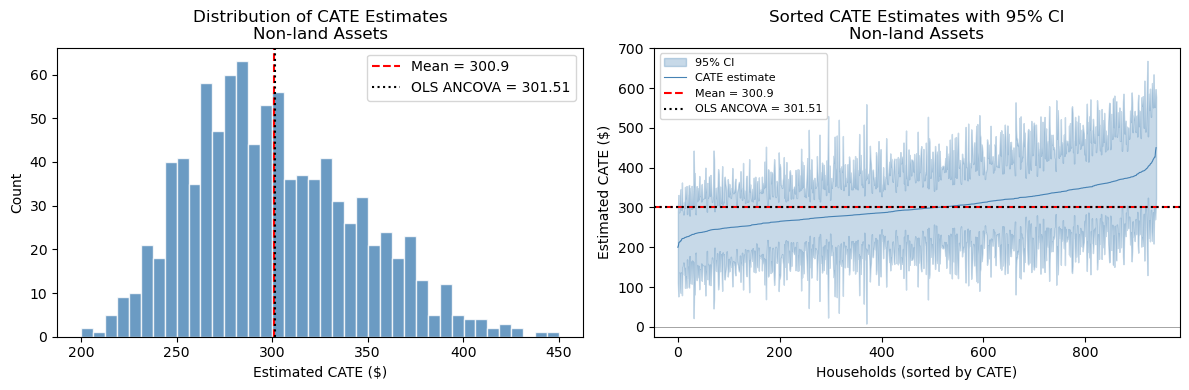


Forest fitted on n=940 observations, p=36 covariates
OLS ANCOVA ATE:   301.51
Causal Forest ATE: 300.87


In [7]:
# ── Data preparation ──────────────────────────────────────────
outcome = 'asset_total_ppp1'
data_clean = data_hh[data_hh[outcome].notna()].copy()

Y = data_clean[outcome].values                    # endline assets
D = data_clean['treat'].values                    # treatment indicator
X = data_clean[covariate_cols].fillna(0).values   # baseline covariates

# ── Fit honest causal forest ──────────────────────────────────
# honest=True: separate subsamples for tree building and leaf estimation
# n_estimators=2000: more trees = more stable CATE estimates
# min_samples_leaf=5: prevents overfitting in small leaves
# inference=True: enables confidence intervals via jackknife
cf = CausalForest(
    n_estimators=2000,
    min_samples_leaf=5,
    max_depth=None,
    honest=True,
    inference=True,
    random_state=42
)

cf.fit(X, D, Y)

# ── Get CATE estimates and confidence intervals ───────────────
tau_hat = cf.predict(X).flatten()                 # point estimates
tau_lb, tau_ub = cf.predict_interval(             # 95% CI
    X, alpha=0.05
)
tau_lb = tau_lb.flatten()
tau_ub = tau_ub.flatten()

# ── Summary statistics ────────────────────────────────────────
print(f"=== CATE Summary: {outcome} ===")
print(f"Mean CATE (ATE):   {tau_hat.mean():.2f}")
print(f"SD of CATEs:       {tau_hat.std():.2f}")
print(f"Min CATE:          {tau_hat.min():.2f}")
print(f"Max CATE:          {tau_hat.max():.2f}")
print(f"Share tau > 0:     {(tau_hat > 0).mean():.3f}")
print(f"Share tau > 200:   {(tau_hat > 200).mean():.3f}")

# ── Plot CATE distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of CATE estimates
axes[0].hist(tau_hat, bins=40, edgecolor='white', color='steelblue', alpha=0.8)
axes[0].axvline(tau_hat.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {tau_hat.mean():.1f}')
axes[0].axvline(301.51, color='black', linestyle=':', linewidth=1.5,
                label='OLS ANCOVA = 301.51')
axes[0].set_xlabel('Estimated CATE ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of CATE Estimates\nNon-land Assets')
axes[0].legend()

# Right: sorted CATE with confidence intervals
sort_idx = np.argsort(tau_hat)
x_plot   = np.arange(len(tau_hat))

axes[1].fill_between(x_plot,
                    tau_lb[sort_idx],
                    tau_ub[sort_idx],
                    alpha=0.3, color='steelblue', label='95% CI')
axes[1].plot(x_plot, tau_hat[sort_idx],
            color='steelblue', linewidth=0.8, label='CATE estimate')
axes[1].axhline(tau_hat.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean = {tau_hat.mean():.1f}')
axes[1].axhline(301.51, color='black', linestyle=':',
                linewidth=1.5, label='OLS ANCOVA = 301.51')
axes[1].axhline(0, color='grey', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Households (sorted by CATE)')
axes[1].set_ylabel('Estimated CATE ($)')
axes[1].set_title('Sorted CATE Estimates with 95% CI\nNon-land Assets')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('cate_assets.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nForest fitted on n={len(Y)} observations, p={X.shape[1]} covariates")
print(f"OLS ANCOVA ATE:   301.51")
print(f"Causal Forest ATE: {tau_hat.mean():.2f}")

=== BLP TEST: Heterogeneity in Non-land Assets ===
beta_1 (ATE):          295.513  (SE=21.903, p=0.0000)
beta_2 (heterogeneity):9.741  (SE=0.488, p=0.0000)

H0: beta_2 = 0 (no heterogeneity)
REJECT H0 — statistically significant heterogeneity detected

=== GATEs: Group Average Treatment Effects ===
Group          GATE       SE    p-value               95% CI
------------------------------------------------------------
G1          -207.11    44.18     0.0000 [ -293.71, -120.51]
G2           134.61    45.74     0.0033 [   44.96,  224.25]
G3           403.32    45.37     0.0000 [  314.40,  492.23]
G4           851.14    46.30     0.0000 [  760.38,  941.89]

G4 - G1: 1058.25 (SE=64.06, p=0.0000)

=== CLAN: Baseline Characteristics by CATE Quartile ===
Variable                         G1 (Low)  G4 (High)     Diff    p-value
----------------------------------------------------------------------
b_age                              33.247     38.588    5.340   0.0001 ***
b_married              

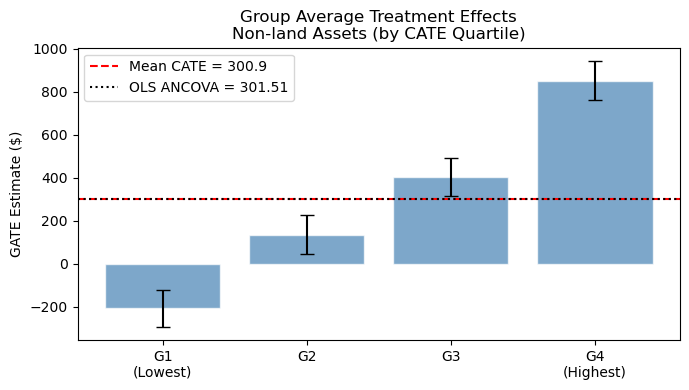

In [8]:
# ── Assumes cf, tau_hat, X, Y, D, data_clean already exist ───

# ── STEP 1: Nuisance estimates needed for BLP ─────────────────

# B(X) — baseline outcome function (regression forest on controls)
# In RCT p(X) = 0.5 exactly — no need to estimate
rf_baseline = RegressionForest(
    n_estimators=2000,
    min_samples_leaf=5,
    honest=True,
    random_state=42
)
rf_baseline.fit(X, Y)
B_hat = rf_baseline.predict(X).flatten()   # baseline function B(X_i)

p_hat = D.mean()                               # known propensity in RCT
S_hat = tau_hat                            # CATE from causal forest
S_bar = S_hat.mean()                       # mean of CATE estimates

# Treatment residual
D_tilde = D - p_hat                        # D_i - 0.5

# ── STEP 2: BLP — Heterogeneity Test ─────────────────────────
# Y_i = a1*B(X_i) + b1*(D_i - p) + b2*(D_i - p)*(S(X_i) - S_bar) + e_i
# b1 = ATE, b2 = heterogeneity test statistic

blp_df = pd.DataFrame({
    'Y':        Y,
    'B_hat':    B_hat,
    'D_tilde':  D_tilde,
    'DS_tilde': D_tilde * (S_hat - S_bar)   # interaction term
})

blp_model = smf.ols(
    'Y ~ B_hat + D_tilde + DS_tilde - 1',   # -1 removes intercept (absorbed by B_hat)
    data=blp_df
).fit(cov_type='HC1')

print("=== BLP TEST: Heterogeneity in Non-land Assets ===")
print(f"beta_1 (ATE):          {blp_model.params['D_tilde']:.3f}  "
      f"(SE={blp_model.bse['D_tilde']:.3f}, p={blp_model.pvalues['D_tilde']:.4f})")
print(f"beta_2 (heterogeneity):{blp_model.params['DS_tilde']:.3f}  "
      f"(SE={blp_model.bse['DS_tilde']:.3f}, p={blp_model.pvalues['DS_tilde']:.4f})")
print(f"\nH0: beta_2 = 0 (no heterogeneity)")
if blp_model.pvalues['DS_tilde'] < 0.05:
    print("REJECT H0 — statistically significant heterogeneity detected")
else:
    print("FAIL TO REJECT H0 — no significant heterogeneity")

# ── STEP 3: GATEs — Group Average Treatment Effects ───────────
# Divide into quartiles by predicted CATE
# Y_i = a1*B(X_i) + sum_k gamma_k * I(G_k) + e_i

quartile_labels = pd.qcut(S_hat, q=4, labels=['G1','G2','G3','G4'])

gate_df = pd.DataFrame({
    'Y':      Y,
    'B_hat':  B_hat,
    'G1':     (quartile_labels == 'G1').astype(int),
    'G2':     (quartile_labels == 'G2').astype(int),
    'G3':     (quartile_labels == 'G3').astype(int),
    'G4':     (quartile_labels == 'G4').astype(int),
    'D_tilde': D_tilde
})

# Following slide 16: Y_i = a1*B(X_i) + sum_k gamma_k*I(G_k) + e_i
# gamma_k estimated using D_tilde interactions
gate_df['G1D'] = gate_df['G1'] * gate_df['D_tilde']
gate_df['G2D'] = gate_df['G2'] * gate_df['D_tilde']
gate_df['G3D'] = gate_df['G3'] * gate_df['D_tilde']
gate_df['G4D'] = gate_df['G4'] * gate_df['D_tilde']

gate_model = smf.ols(
    'Y ~ B_hat + G1D + G2D + G3D + G4D - 1',
    data=gate_df
).fit(cov_type='HC1')

print("\n=== GATEs: Group Average Treatment Effects ===")
print(f"{'Group':<8} {'GATE':>10} {'SE':>8} {'p-value':>10} {'95% CI':>20}")
print("-" * 60)
for g in ['G1D','G2D','G3D','G4D']:
    coef = gate_model.params[g]
    se   = gate_model.bse[g]
    pval = gate_model.pvalues[g]
    ci_l = gate_model.conf_int().loc[g, 0]
    ci_u = gate_model.conf_int().loc[g, 1]
    label = g.replace('D','')
    print(f"{label:<8} {coef:>10.2f} {se:>8.2f} {pval:>10.4f} [{ci_l:>8.2f}, {ci_u:>7.2f}]")

# Test G4 - G1
g4_g1     = gate_model.params['G4D'] - gate_model.params['G1D']
g4_g1_se  = np.sqrt(gate_model.cov_params().loc['G4D','G4D'] +
                    gate_model.cov_params().loc['G1D','G1D'] -
                    2*gate_model.cov_params().loc['G4D','G1D'])
g4_g1_t   = g4_g1 / g4_g1_se
g4_g1_p   = 2 * (1 - __import__('scipy').stats.t.cdf(abs(g4_g1_t), df=len(Y)-5))

print(f"\nG4 - G1: {g4_g1:.2f} (SE={g4_g1_se:.2f}, p={g4_g1_p:.4f})")

# ── STEP 4: CLAN — Classification Analysis ────────────────────
# Compare baseline characteristics between G1 (lowest CATE) and G4 (highest CATE)

clan_vars = [
    'b_age', 'b_married', 'b_children', 'b_hhsize', 'b_edu',
    'asset_total_ppp0', 'cons_nondurable_ppp0', 'fs_hhfoodindexnew0',
    'asset_niceroof0', 'given_mpesa',
    'femalerec', 'large', 'monthly',
]

data_clean['quartile'] = np.array(quartile_labels)
g1_data = data_clean[data_clean['quartile'] == 'G1']
g4_data = data_clean[data_clean['quartile'] == 'G4']

print("\n=== CLAN: Baseline Characteristics by CATE Quartile ===")
print(f"{'Variable':<30} {'G1 (Low)':>10} {'G4 (High)':>10} {'Diff':>8} {'p-value':>10}")
print("-" * 70)

from scipy import stats

for var in clan_vars:
    g1_vals = g1_data[var].dropna()
    g4_vals = g4_data[var].dropna()
    diff = g4_vals.mean() - g1_vals.mean()
    tstat, pval = stats.ttest_ind(g4_vals, g1_vals, equal_var=False)
    sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    print(f"{var:<30} {g1_vals.mean():>10.3f} {g4_vals.mean():>10.3f} "
          f"{diff:>8.3f} {pval:>8.4f} {sig}")

# ── STEP 5: Plot GATEs ────────────────────────────────────────
gates   = [gate_model.params[f'G{k}D'] for k in range(1,5)]
gate_se = [gate_model.bse[f'G{k}D'] for k in range(1,5)]
ci95    = [1.96 * se for se in gate_se]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1,5), gates, yerr=ci95, capsize=5,
       color='steelblue', alpha=0.7, edgecolor='white')
ax.axhline(tau_hat.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean CATE = {tau_hat.mean():.1f}')
ax.axhline(301.51, color='black', linestyle=':',
           linewidth=1.5, label='OLS ANCOVA = 301.51')
ax.set_xticks(range(1,5))
ax.set_xticklabels(['G1\n(Lowest)', 'G2', 'G3', 'G4\n(Highest)'])
ax.set_ylabel('GATE Estimate ($)')
ax.set_title('Group Average Treatment Effects\nNon-land Assets (by CATE Quartile)')
ax.legend()
plt.tight_layout()
plt.savefig('gates_assets.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Build dataframe with CATE estimates and covariates
cate_df = data_clean[covariate_cols].copy().fillna(0)
cate_df['tau_hat'] = tau_hat

# OLS of tau_hat on all covariates
extra_vars = ['femalerec', 'large', 'monthly']
cate_df[extra_vars] = data_clean[extra_vars].fillna(0).values  # NaN for controls is fine here
formula = 'tau_hat ~ ' + ' + '.join(covariate_cols)
cate_ols = smf.ols(formula, data=cate_df).fit(cov_type='HC1')

# Print only significant ones
results_cate = pd.DataFrame({
    'coef':   cate_ols.params,
    'se':     cate_ols.bse,
    'pvalue': cate_ols.pvalues
}).drop('Intercept')

results_cate = results_cate.sort_values('pvalue')

print("=== OLS of tau_hat on X — significant predictors ===")
print(f"{'Variable':<35} {'Coef':>10} {'SE':>8} {'p-value':>10}")
print("-" * 65)
for var, row in results_cate.iterrows():
    sig = '***' if row['pvalue'] < 0.01 else '**' if row['pvalue'] < 0.05 else '*' if row['pvalue'] < 0.10 else ''
    if row['pvalue'] < 0.10:
        print(f"{var:<35} {row['coef']:>10.3f} {row['se']:>8.3f} {row['pvalue']:>8.4f} {sig}")

=== OLS of tau_hat on X — significant predictors ===
Variable                                  Coef       SE    p-value
-----------------------------------------------------------------
med_hh_healthindex0                     -5.369    1.185   0.0000 ***
ed_index0                               -7.635    1.842   0.0000 ***
ent_business0                          -15.869    4.125   0.0001 ***
fs_hhfoodindexnew0                      -5.056    1.459   0.0005 ***
b_age                                    0.334    0.127   0.0088 ***
b_married                              -11.216    4.752   0.0183 **
b_edu                                   -1.147    0.504   0.0229 **
asset_land_owned_total0                  1.762    1.038   0.0895 *
